# CityBrain — Infrastructure Dataset EDA

**COMP 9130 Final Project — Vancouver Pavement Risk Assessment**

Exploratory Data Analysis for the 10 infrastructure datasets added in v11:

| # | Dataset | Records | Key Features |
|---|---------|---------|-------------|
| 1 | Water Distribution Mains | 67K | Pipe diameter, age, material |
| 2 | Sewer Mains | 40K | Effluent type, material |
| 3 | Public Trees | 186K | Height, diameter, species |
| 4 | Truck Routes | 3 multi-lines | Route type |
| 5 | Zoning Districts | 1.6K | Zoning category/classification |
| 6 | Bikeways | 3.7K | Bikeway type, speed limit, surface |
| 7 | Building Permits | 625K | Project value, type of work, year |
| 8 | Sewer Manholes | 36K | Cover elevation, type |
| 9 | Sewer Catch Basins | 45K | Label, location |
| 10 | Snow Removal Routes | 270 | Route type |

## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json, warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.size'] = 11

DATA = '/content/drive/MyDrive/AI-FinalProject/data'

def load(name, **kw):
    """Load a CSV with semicolon separator, strip BOM."""
    df = pd.read_csv(f'{DATA}/{name}', sep=';', encoding='utf-8-sig', **kw)
    print(f'{name}: {len(df):,} rows x {len(df.columns)} cols')
    return df

def parse_coord(s):
    """Parse 'lat, lon' string from geo_point_2d column."""
    if pd.isna(s): return None, None
    parts = str(s).split(',')
    return float(parts[0].strip()), float(parts[1].strip())

def add_latlon(df):
    """Extract lat/lon from geo_point_2d."""
    if 'geo_point_2d' in df.columns:
        coords = df['geo_point_2d'].apply(parse_coord)
        df['lat'] = coords.apply(lambda x: x[0])
        df['lon'] = coords.apply(lambda x: x[1])
    return df

print('Setup complete.')

Mounted at /content/drive
Setup complete.


---
## 1. Water Distribution Mains (67K)

Underground water pipes — installation date gives **pipe age** (proxy for underground stress on pavement).
Diameter correlates with trench width and disturbance potential.

In [2]:
df_water = load('water_distribution_mains.csv')
print('\nColumns:', df_water.columns.tolist())
print('\nMissing values:')
print(df_water.isnull().sum())
print('\nSample:')
df_water.drop(columns=['Geom'], errors='ignore').head()

water_distribution_mains.csv: 67,169 rows x 6 cols

Columns: ['Geom', 'DIAMETER_MM', 'INSTALLATION_DATE', 'LINING_MATERIAL', 'MATERIAL', 'geo_point_2d']

Missing values:
Geom                     0
DIAMETER_MM             15
INSTALLATION_DATE     1044
LINING_MATERIAL      10740
MATERIAL                 9
geo_point_2d             0
dtype: int64

Sample:


,DIAMETER_MM,INSTALLATION_DATE,LINING_MATERIAL,MATERIAL,geo_point_2d
0,200.0,2004-01-01,blank,Ductile Iron Concrete Lined,"49.238311489621715, -123.15908931700483"
1,200.0,2004-06-21,blank,Ductile Iron Concrete Lined,"49.21875467205955, -123.05792189360392"
2,200.0,2004-06-21,blank,Ductile Iron Concrete Lined,"49.21875499210648, -123.05782150071364"
3,150.0,1972-01-01,Cement Lined,Ductile Iron,"49.28031299103358, -123.09148251123591"
4,300.0,1999-01-01,Cement Lined,Ductile Iron,"49.23815471285245, -123.06493175395195"


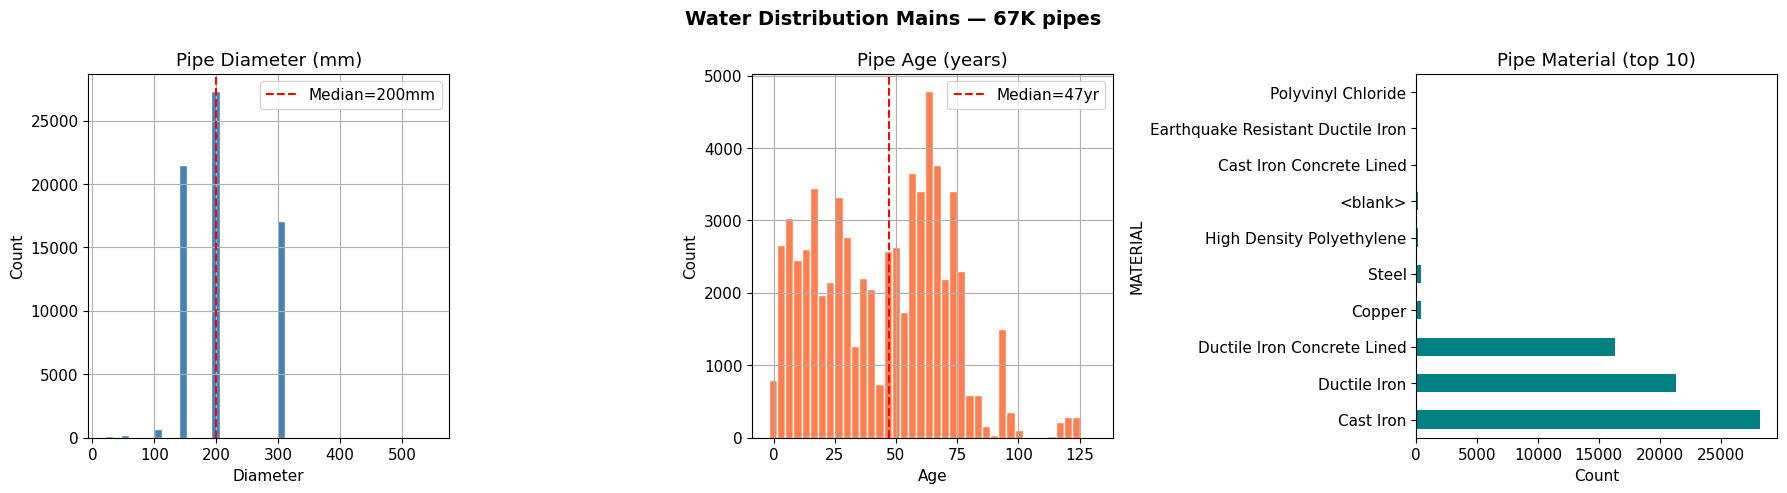


Diameter: mean=208mm, median=200mm
Pipe age: mean=44yr, median=47yr, max=132yr
Oldest pipes from 1892


In [3]:
# Parse installation year
df_water['install_year'] = pd.to_datetime(df_water['INSTALLATION_DATE'], errors='coerce').dt.year
df_water['pipe_age'] = 2024 - df_water['install_year']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Diameter distribution
df_water['DIAMETER_MM'].dropna().hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Pipe Diameter (mm)')
axes[0].set_xlabel('Diameter'); axes[0].set_ylabel('Count')
axes[0].axvline(df_water['DIAMETER_MM'].median(), color='red', ls='--', label=f"Median={df_water['DIAMETER_MM'].median():.0f}mm")
axes[0].legend()

# Pipe age distribution
df_water['pipe_age'].dropna().hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Pipe Age (years)')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Count')
axes[1].axvline(df_water['pipe_age'].median(), color='red', ls='--', label=f"Median={df_water['pipe_age'].median():.0f}yr")
axes[1].legend()

# Material breakdown
df_water['MATERIAL'].value_counts().head(10).plot.barh(ax=axes[2], color='teal')
axes[2].set_title('Pipe Material (top 10)')
axes[2].set_xlabel('Count')

plt.suptitle('Water Distribution Mains — 67K pipes', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nDiameter: mean={df_water["DIAMETER_MM"].mean():.0f}mm, median={df_water["DIAMETER_MM"].median():.0f}mm')
print(f'Pipe age: mean={df_water["pipe_age"].mean():.0f}yr, median={df_water["pipe_age"].median():.0f}yr, max={df_water["pipe_age"].max():.0f}yr')
print(f'Oldest pipes from {df_water["install_year"].min():.0f}')

---
## 2. Sewer Mains (40K)

**Combined** sewers (storm + sanitary in one pipe) are older infrastructure, more likely to cause
ground settlement and pavement damage.

sewer_mains.csv: 40,043 rows x 4 cols

Columns: ['Effluent Type', 'Material', 'Geom', 'geo_point_2d']

Missing values:
Effluent Type     0
Material         10
Geom              0
geo_point_2d      0
dtype: int64


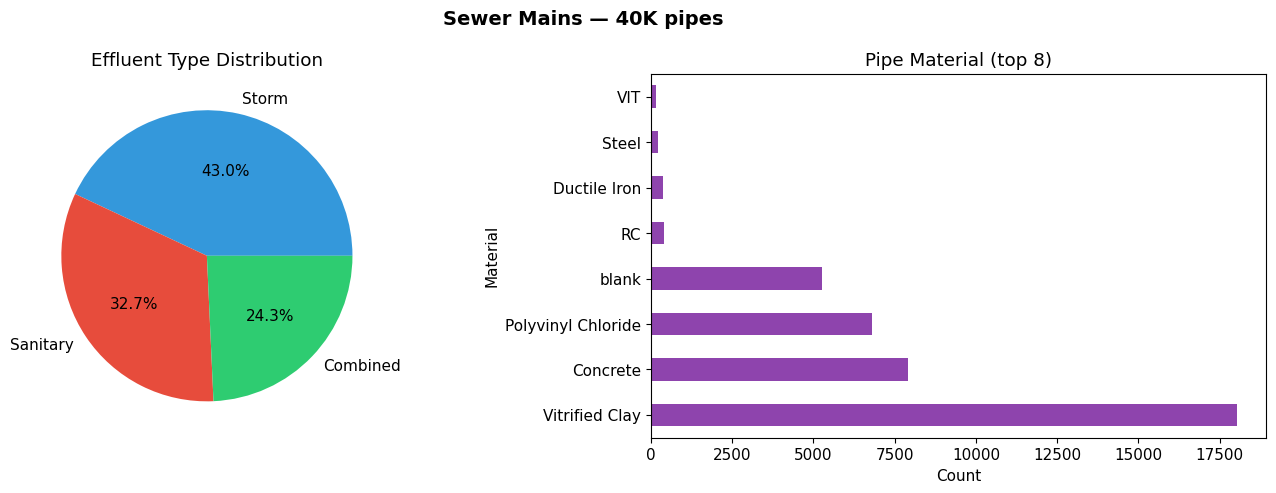


Combined sewer ratio: 24.3% — older infrastructure, higher risk


In [4]:
df_sewer = load('sewer_mains.csv')
print('\nColumns:', df_sewer.columns.tolist())
print('\nMissing values:')
print(df_sewer.isnull().sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Effluent type
eff = df_sewer['Effluent Type'].value_counts()
eff.plot.pie(ax=axes[0], autopct='%1.1f%%', colors=['#3498db','#e74c3c','#2ecc71','#f39c12'])
axes[0].set_title('Effluent Type Distribution')
axes[0].set_ylabel('')

# Material
mat = df_sewer['Material'].value_counts().head(8)
mat.plot.barh(ax=axes[1], color='#8e44ad')
axes[1].set_title('Pipe Material (top 8)')
axes[1].set_xlabel('Count')

plt.suptitle('Sewer Mains — 40K pipes', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

combined_pct = (df_sewer['Effluent Type'] == 'Combined').mean() * 100
print(f'\nCombined sewer ratio: {combined_pct:.1f}% — older infrastructure, higher risk')

---
## 3. Public Trees (186K)

Tree roots lift and crack pavement. Larger diameter trees = bigger root systems = more damage.
Used as **root pressure proxy** via tree count within 30m radius.

In [5]:
df_trees = load('public_trees.csv')
print('\nColumns:', df_trees.columns.tolist())
print('\nMissing values (selected):')
print(df_trees[['height_(m)','diameter_(cm)','Date planted','Common name']].isnull().sum())
print('\nSample:')
df_trees[['Common name','height_(m)','diameter_(cm)','Date planted','Address']].head()

public_trees.csv: 186,496 rows x 11 cols

Columns: ['Asset ID', 'Address', 'Common name', 'Genus name', 'Species name', 'Cultivar name', 'height_(m)', 'diameter_(cm)', 'Date planted', 'Geom', 'geo_point_2d']

Missing values (selected):
height_(m)            0
diameter_(cm)         0
Date planted     108188
Common name          50
dtype: int64

Sample:


,Common name,height_(m),diameter_(cm),Date planted,Address
0,JAPANESE SNOWBELL,7.6,10.2,1999-01-19,723 W 69TH AV
1,JAPANESE SNOWBELL,7.6,19.1,1999-01-18,704 W 69TH AV
2,JAPANESE SNOWBELL,7.6,12.7,1999-01-18,761 W 69TH AV
3,WORPLESDON SWEETGUM,10.7,40.6,1999-01-18,347 E 65TH AV
4,WORPLESDON SWEETGUM,7.6,22.9,1999-01-18,377 E 65TH AV


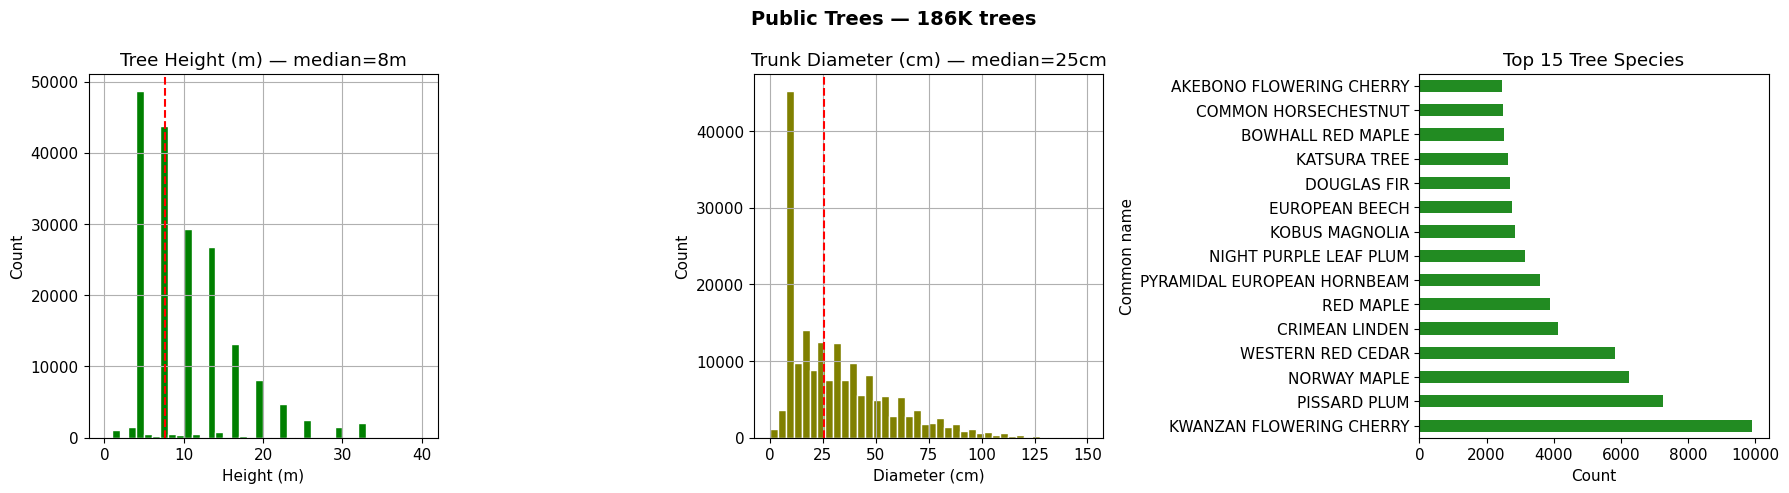


Height: mean=10.4m, max=63m
Diameter: mean=32.2cm, max=6673cm
Species: 1312 unique


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Height distribution
h = df_trees['height_(m)'].dropna()
h[h.between(0, 50)].hist(bins=40, ax=axes[0], color='green', edgecolor='white')
axes[0].set_title(f'Tree Height (m) — median={h.median():.0f}m')
axes[0].set_xlabel('Height (m)'); axes[0].set_ylabel('Count')
axes[0].axvline(h.median(), color='red', ls='--')

# Diameter distribution
d = df_trees['diameter_(cm)'].dropna()
d[d.between(0, 150)].hist(bins=40, ax=axes[1], color='olive', edgecolor='white')
axes[1].set_title(f'Trunk Diameter (cm) — median={d.median():.0f}cm')
axes[1].set_xlabel('Diameter (cm)'); axes[1].set_ylabel('Count')
axes[1].axvline(d.median(), color='red', ls='--')

# Top species
df_trees['Common name'].value_counts().head(15).plot.barh(ax=axes[2], color='forestgreen')
axes[2].set_title('Top 15 Tree Species')
axes[2].set_xlabel('Count')

plt.suptitle('Public Trees — 186K trees', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nHeight: mean={h.mean():.1f}m, max={h.max():.0f}m')
print(f'Diameter: mean={d.mean():.1f}cm, max={d.max():.0f}cm')
print(f'Species: {df_trees["Common name"].nunique()} unique')

---
## 4. Truck Routes

Heavy truck traffic causes **4th-power axle load damage** — a single overloaded truck can do
more damage than thousands of cars. Binary feature: is the road on a truck route?

In [7]:
df_truck = load('truck_routes.csv')
print('\nColumns:', df_truck.columns.tolist())
print('\nRoute types:')
print(df_truck['TYPE'].value_counts())

# Count coordinate points to estimate coverage
total_coords = 0
for _, row in df_truck.iterrows():
    geom = json.loads(row['Geom'])
    if geom['type'] == 'MultiLineString':
        for line in geom['coordinates']:
            total_coords += len(line)
    elif geom['type'] == 'LineString':
        total_coords += len(geom['coordinates'])

print(f'\nTotal coordinate points: {total_coords:,} (defines the truck route network geometry)')
print('Used as binary feature: is_truck_route (proximity-based matching)')

truck_routes.csv: 2 rows x 3 cols

Columns: ['TYPE', 'Geom', 'geo_point_2d']

Route types:
TYPE
Restricted Access Truck Route    1
Truck Route                      1
Name: count, dtype: int64

Total coordinate points: 8,619 (defines the truck route network geometry)
Used as binary feature: is_truck_route (proximity-based matching)


---
## 5. Zoning Districts (1.6K)

Land use affects traffic patterns — **industrial** zones have more heavy vehicles,
**commercial** zones have more frequent stops/starts.

zoning_districts.csv: 1,612 rows x 7 cols

Columns: ['Geom', 'Object ID', 'Zoning Classification', 'Zoning Category', 'Zoning District', 'CD-1 Number', 'geo_point_2d']


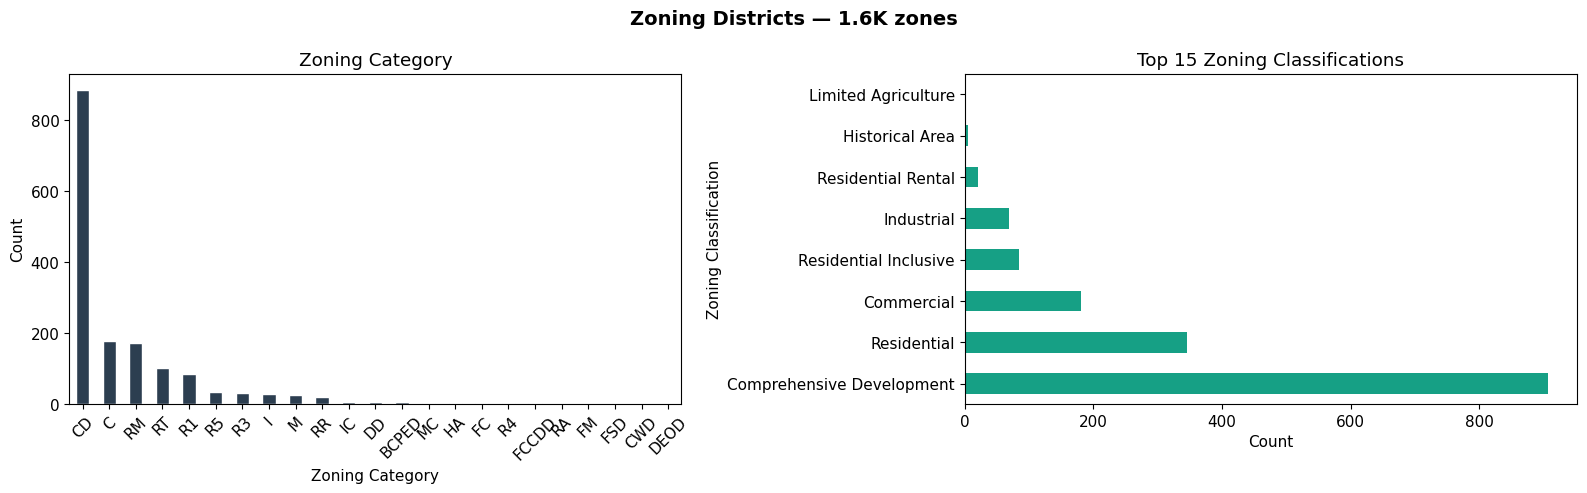


Categories: 23
Classifications: 8
Industrial zones: 0.0%


In [8]:
df_zone = load('zoning_districts.csv')
print('\nColumns:', df_zone.columns.tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Zoning category
cat = df_zone['Zoning Category'].value_counts()
cat.plot.bar(ax=axes[0], color='#2c3e50', edgecolor='white')
axes[0].set_title('Zoning Category')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=45)

# Zoning classification (top 15)
cls = df_zone['Zoning Classification'].value_counts().head(15)
cls.plot.barh(ax=axes[1], color='#16a085')
axes[1].set_title('Top 15 Zoning Classifications')
axes[1].set_xlabel('Count')

plt.suptitle('Zoning Districts — 1.6K zones', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nCategories: {df_zone["Zoning Category"].nunique()}')
print(f'Classifications: {df_zone["Zoning Classification"].nunique()}')
industrial_pct = (df_zone['Zoning Category'].str.contains('Industrial', case=False, na=False)).mean() * 100
print(f'Industrial zones: {industrial_pct:.1f}%')

---
## 6. Bikeways (3.7K)

Bikeway presence indicates road type and speed limits.
Protected bike lanes often mean recent road upgrades = newer pavement.

bikeways.csv: 3,705 rows x 24 cols

Columns: ['Object ID', 'Bike route name', 'Street name', 'Bikeway type', 'Subtype', 'Status', 'Street segment type', 'Overall direction', 'Bikeway direction', 'Vehicle direction', 'Speed limit', 'Surface type', 'AAA Network', 'AAA segment', 'W/N bound type', 'E/S bound type', 'Snow removal', 'Segment length', 'Year of construction', 'Construction note', 'Upgrade year', 'Notes', 'Geom', 'geo_point_2d']

Missing values (selected):
Bikeway type              0
Speed limit             448
Surface type             12
Year of construction     18
dtype: int64


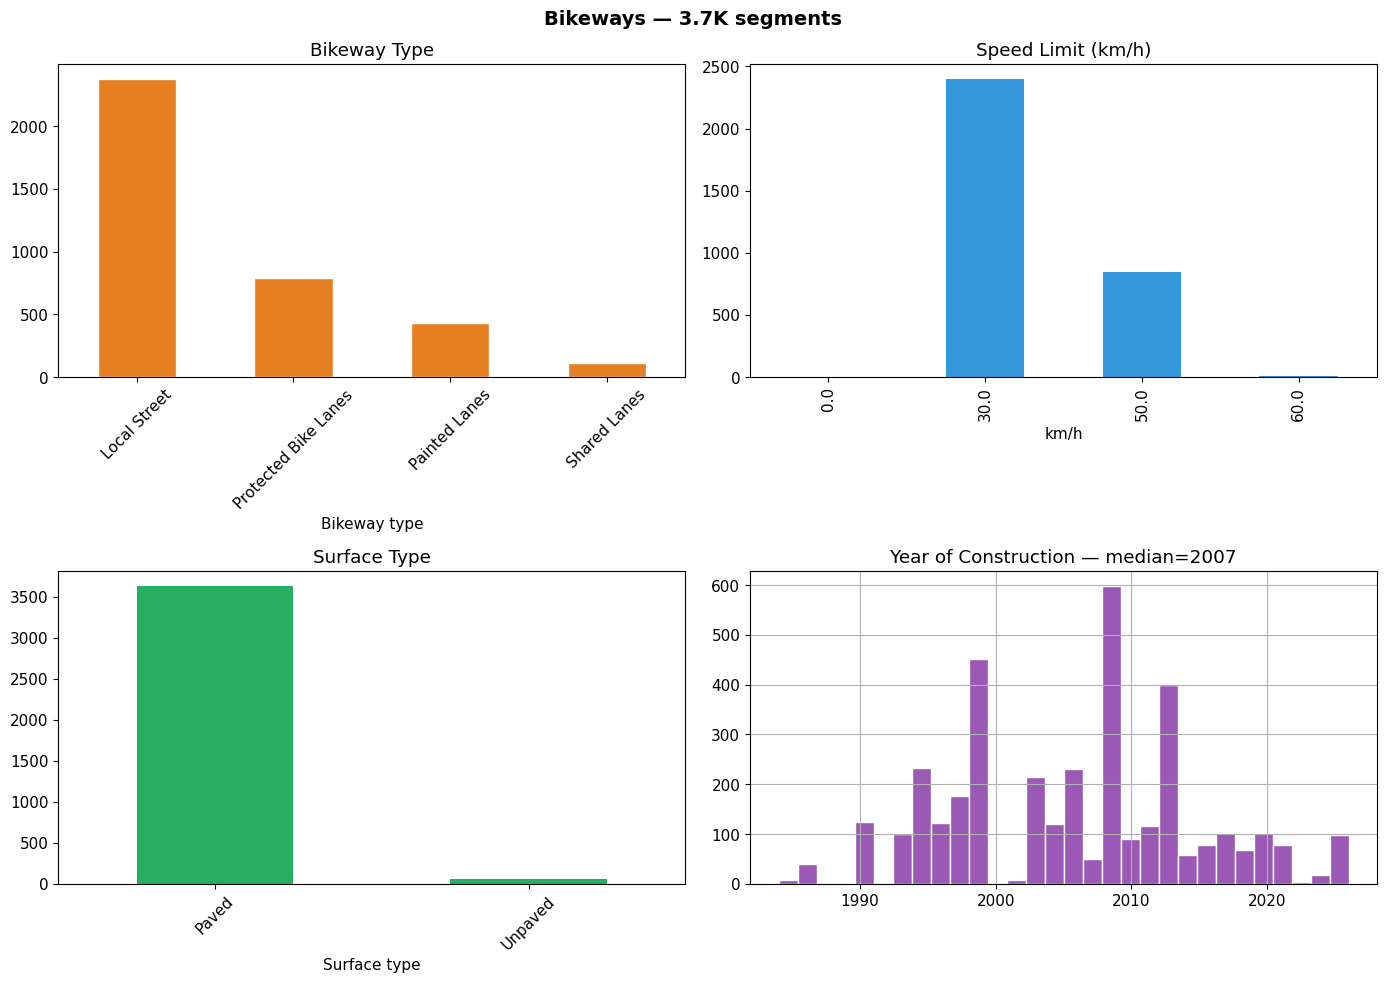


Snow removal on bikeways: 1355 / 3705


In [9]:
df_bike = load('bikeways.csv')
print('\nColumns:', df_bike.columns.tolist())
print('\nMissing values (selected):')
print(df_bike[['Bikeway type','Speed limit','Surface type','Year of construction']].isnull().sum())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bikeway type
df_bike['Bikeway type'].value_counts().plot.bar(ax=axes[0,0], color='#e67e22', edgecolor='white')
axes[0,0].set_title('Bikeway Type'); axes[0,0].tick_params(axis='x', rotation=45)

# Speed limit
df_bike['Speed limit'].value_counts().sort_index().plot.bar(ax=axes[0,1], color='#3498db')
axes[0,1].set_title('Speed Limit (km/h)'); axes[0,1].set_xlabel('km/h')

# Surface type
df_bike['Surface type'].value_counts().plot.bar(ax=axes[1,0], color='#27ae60')
axes[1,0].set_title('Surface Type'); axes[1,0].tick_params(axis='x', rotation=45)

# Year of construction
yoc = pd.to_numeric(df_bike['Year of construction'], errors='coerce').dropna()
yoc[yoc > 1950].hist(bins=30, ax=axes[1,1], color='#9b59b6', edgecolor='white')
axes[1,1].set_title(f'Year of Construction — median={yoc.median():.0f}')

plt.suptitle('Bikeways — 3.7K segments', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nSnow removal on bikeways: {(df_bike["Snow removal"]=="Yes").sum()} / {len(df_bike)}')

---
## 7. Building Permits (625K)

Recent construction near a road segment → heavy equipment, temporary trenching, utility connections.
Used as **permit_count_200m** and **permit_avg_value** within 200m radius (2018–2024).

In [10]:
df_permit = load('building_permits.csv')
print('\nColumns:', df_permit.columns.tolist())
print('\nMissing values (key cols):')
print(df_permit[['ProjectValue','TypeOfWork','IssueYear','geo_point_2d']].isnull().sum())
print('\nSample:')
df_permit[['PermitNumber','IssueYear','TypeOfWork','ProjectValue','PropertyUse','GeoLocalArea']].head()

building_permits.csv: 50,324 rows x 20 cols

Columns: ['PermitNumber', 'PermitNumberCreatedDate', 'IssueDate', 'PermitElapsedDays', 'ProjectValue', 'TypeOfWork', 'Address', 'ProjectDescription', 'PermitCategory', 'Applicant', 'ApplicantAddress', 'PropertyUse', 'SpecificUseCategory', 'BuildingContractor', 'BuildingContractorAddress', 'IssueYear', 'GeoLocalArea', 'Geom', 'YearMonth', 'geo_point_2d']

Missing values (key cols):
ProjectValue      0
TypeOfWork        0
IssueYear         0
geo_point_2d    368
dtype: int64

Sample:


,PermitNumber,IssueYear,TypeOfWork,ProjectValue,PropertyUse,GeoLocalArea
0,BP-2024-01817,2024,New Building,883650.0,Dwelling Uses,Shaughnessy
1,BP-2025-00647,2025,New Building,990000.0,Dwelling Uses,Kitsilano
2,BP-2024-04639,2025,New Building,1000000.0,Dwelling Uses,NaN
3,DB-2024-01409,2025,New Building,880000.0,Dwelling Uses,Dunbar-Southlands
4,BP-2024-03313,2025,New Building,1200000.0,Dwelling Uses,Dunbar-Southlands


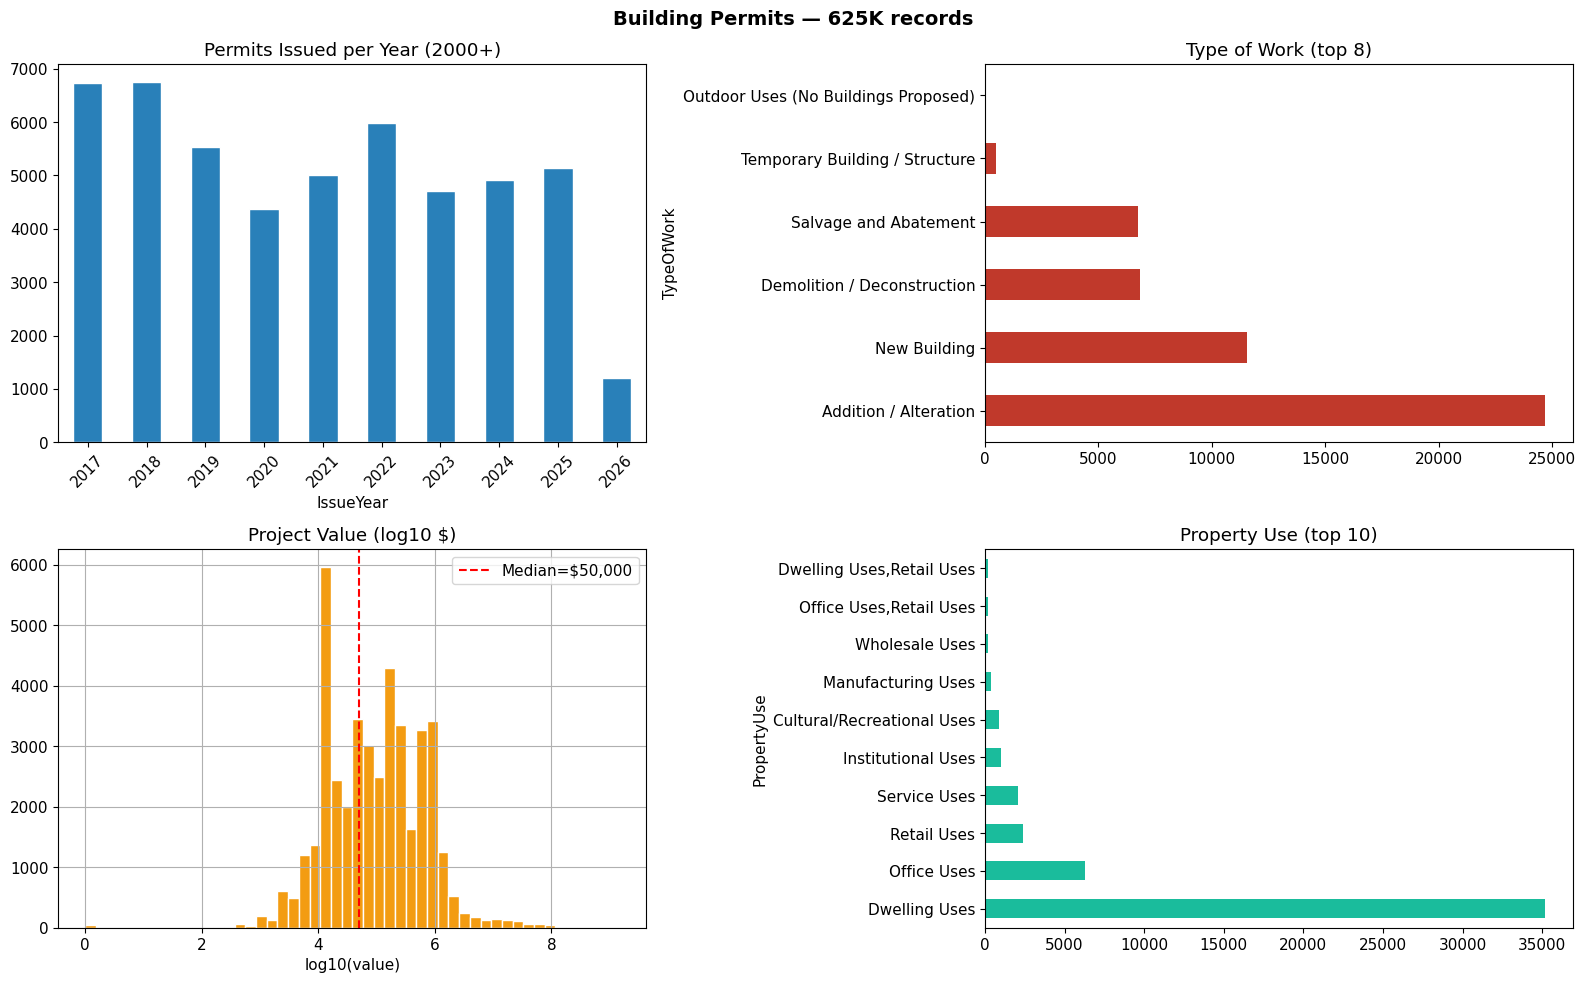


Recent permits (2018-2024): 43,596 (86.6%)
Median project value: $50,000
With coordinates: 49,956 (99.3%)


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Permits per year
yr = df_permit['IssueYear'].dropna()
yr[yr >= 2000].value_counts().sort_index().plot.bar(ax=axes[0,0], color='#2980b9', edgecolor='white')
axes[0,0].set_title('Permits Issued per Year (2000+)')
axes[0,0].tick_params(axis='x', rotation=45)

# Type of work
df_permit['TypeOfWork'].value_counts().head(8).plot.barh(ax=axes[0,1], color='#c0392b')
axes[0,1].set_title('Type of Work (top 8)')

# Project value distribution (log scale)
val = df_permit['ProjectValue'].dropna()
val[val > 0].apply(np.log10).hist(bins=50, ax=axes[1,0], color='#f39c12', edgecolor='white')
axes[1,0].set_title('Project Value (log10 $)')
axes[1,0].set_xlabel('log10(value)')
axes[1,0].axvline(np.log10(val.median()), color='red', ls='--', label=f'Median=${val.median():,.0f}')
axes[1,0].legend()

# Property use
df_permit['PropertyUse'].value_counts().head(10).plot.barh(ax=axes[1,1], color='#1abc9c')
axes[1,1].set_title('Property Use (top 10)')

plt.suptitle('Building Permits — 625K records', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

recent = df_permit[df_permit['IssueYear'] >= 2018]
print(f'\nRecent permits (2018-2024): {len(recent):,} ({len(recent)/len(df_permit)*100:.1f}%)')
print(f'Median project value: ${val.median():,.0f}')
print(f'With coordinates: {df_permit["geo_point_2d"].notna().sum():,} ({df_permit["geo_point_2d"].notna().mean()*100:.1f}%)')

---
## 8. Sewer Manholes (36K)

Manholes are **weak points** in the pavement surface — the cover sits in a metal frame
that settles differently from surrounding asphalt. More manholes = more potential cracking.

sewer_manholes.csv: 35,922 rows x 5 cols

Columns: ['COVER_ELEVATION_M', 'TYPE', 'Geom', 'Geo Local Area', 'geo_point_2d']

Missing values:
COVER_ELEVATION_M    669
TYPE                   0
Geom                   0
Geo Local Area       281
geo_point_2d           0
dtype: int64


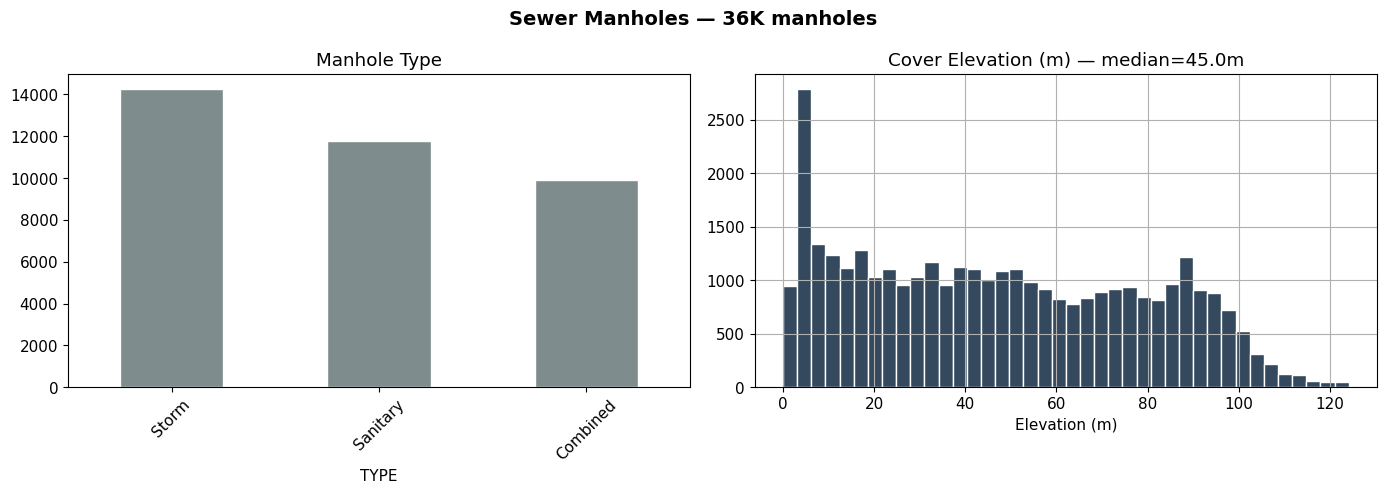


Manholes per neighbourhood (top 5):
  Renfrew-Collingwood: 3,363
  Kensington-Cedar Cottage: 2,624
  Hastings-Sunrise: 2,480
  Mount Pleasant: 2,083
  Downtown: 1,974


In [12]:
df_manhole = load('sewer_manholes.csv')
print('\nColumns:', df_manhole.columns.tolist())
print('\nMissing values:')
print(df_manhole.isnull().sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Type distribution
df_manhole['TYPE'].value_counts().plot.bar(ax=axes[0], color='#7f8c8d', edgecolor='white')
axes[0].set_title('Manhole Type'); axes[0].tick_params(axis='x', rotation=45)

# Cover elevation
elev = df_manhole['COVER_ELEVATION_M'].dropna()
elev[elev.between(0, 200)].hist(bins=40, ax=axes[1], color='#34495e', edgecolor='white')
axes[1].set_title(f'Cover Elevation (m) — median={elev.median():.1f}m')
axes[1].set_xlabel('Elevation (m)')

plt.suptitle('Sewer Manholes — 36K manholes', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Per-neighbourhood density
area_counts = df_manhole['Geo Local Area'].value_counts()
print(f'\nManholes per neighbourhood (top 5):')
for area, cnt in area_counts.head(5).items():
    print(f'  {area}: {cnt:,}')

---
## 9. Sewer Catch Basins (45K)

Catch basins collect surface runoff — their density indicates **drainage quality**.
Poor drainage = water infiltration = accelerated pavement deterioration.

sewer_catch_basins.csv: 44,834 rows x 4 cols

Columns: ['LABEL', 'Geom', 'Geo Local Area', 'geo_point_2d']

Missing values:
LABEL               0
Geom                0
Geo Local Area    276
geo_point_2d        0
dtype: int64


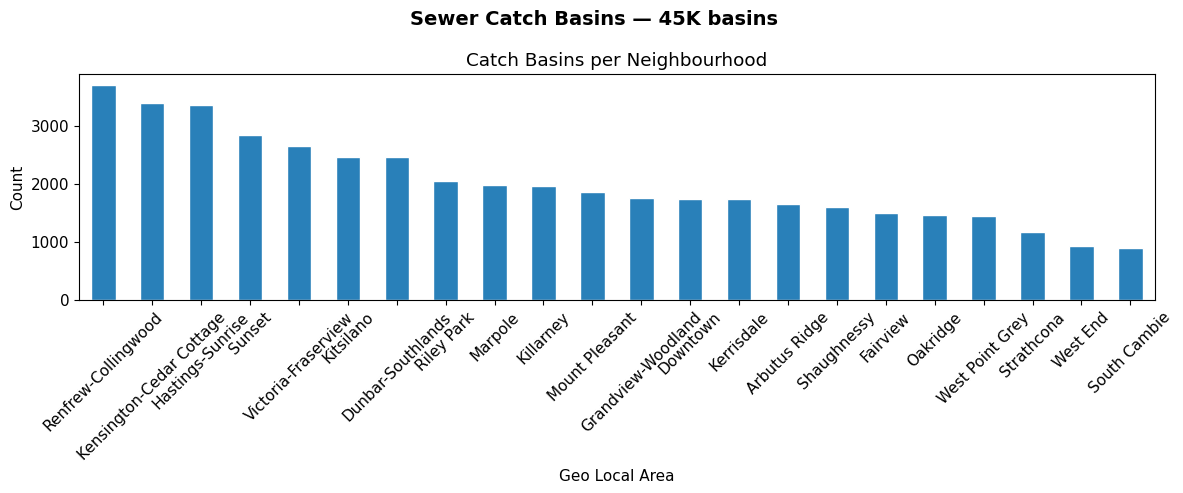


Neighbourhoods: 22
Mean per neighbourhood: 2025
Most basins: Renfrew-Collingwood (3,709)
Fewest basins: South Cambie (891)


In [13]:
df_basin = load('sewer_catch_basins.csv')
print('\nColumns:', df_basin.columns.tolist())
print('\nMissing values:')
print(df_basin.isnull().sum())

fig, ax = plt.subplots(figsize=(12, 5))
area = df_basin['Geo Local Area'].value_counts()
area.plot.bar(ax=ax, color='#2980b9', edgecolor='white')
ax.set_title('Catch Basins per Neighbourhood')
ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=45)
plt.suptitle('Sewer Catch Basins — 45K basins', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nNeighbourhoods: {df_basin["Geo Local Area"].nunique()}')
print(f'Mean per neighbourhood: {area.mean():.0f}')
print(f'Most basins: {area.index[0]} ({area.iloc[0]:,})')
print(f'Fewest basins: {area.index[-1]} ({area.iloc[-1]:,})')

---
## 10. Snow Removal Routes (270)

Roads on snow removal routes experience **salt corrosion** + **plow scraping** damage.
Used as binary feature: `is_snow_route`.

snow_removal_routes.csv: 269 rows x 5 cols

Columns: ['ST_ROUTE_ID', 'NAME', 'ROUTE_TYPE', 'Geom', 'geo_point_2d']

Route types:
ROUTE_TYPE
Priority Hills          181
Bridge Deck Sidewalk     50
Bike Route               16
Street Route             15
Pedestrian Pathway        7
Name: count, dtype: int64

Total routes: 269
Unique route IDs: 269


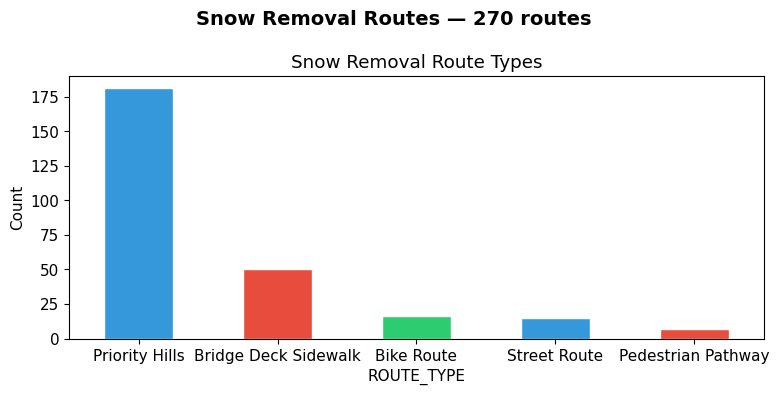

In [14]:
df_snow = load('snow_removal_routes.csv')
print('\nColumns:', df_snow.columns.tolist())
print('\nRoute types:')
print(df_snow['ROUTE_TYPE'].value_counts())
print(f'\nTotal routes: {len(df_snow)}')
print(f'Unique route IDs: {df_snow["ST_ROUTE_ID"].nunique()}')

fig, ax = plt.subplots(figsize=(8, 4))
df_snow['ROUTE_TYPE'].value_counts().plot.bar(ax=ax, color=['#3498db','#e74c3c','#2ecc71'], edgecolor='white')
ax.set_title('Snow Removal Route Types')
ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=0)
plt.suptitle('Snow Removal Routes — 270 routes', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 11. Spatial Distribution — All Infrastructure Datasets

Overlay all 10 infrastructure datasets on one map to visualise spatial density across Vancouver.

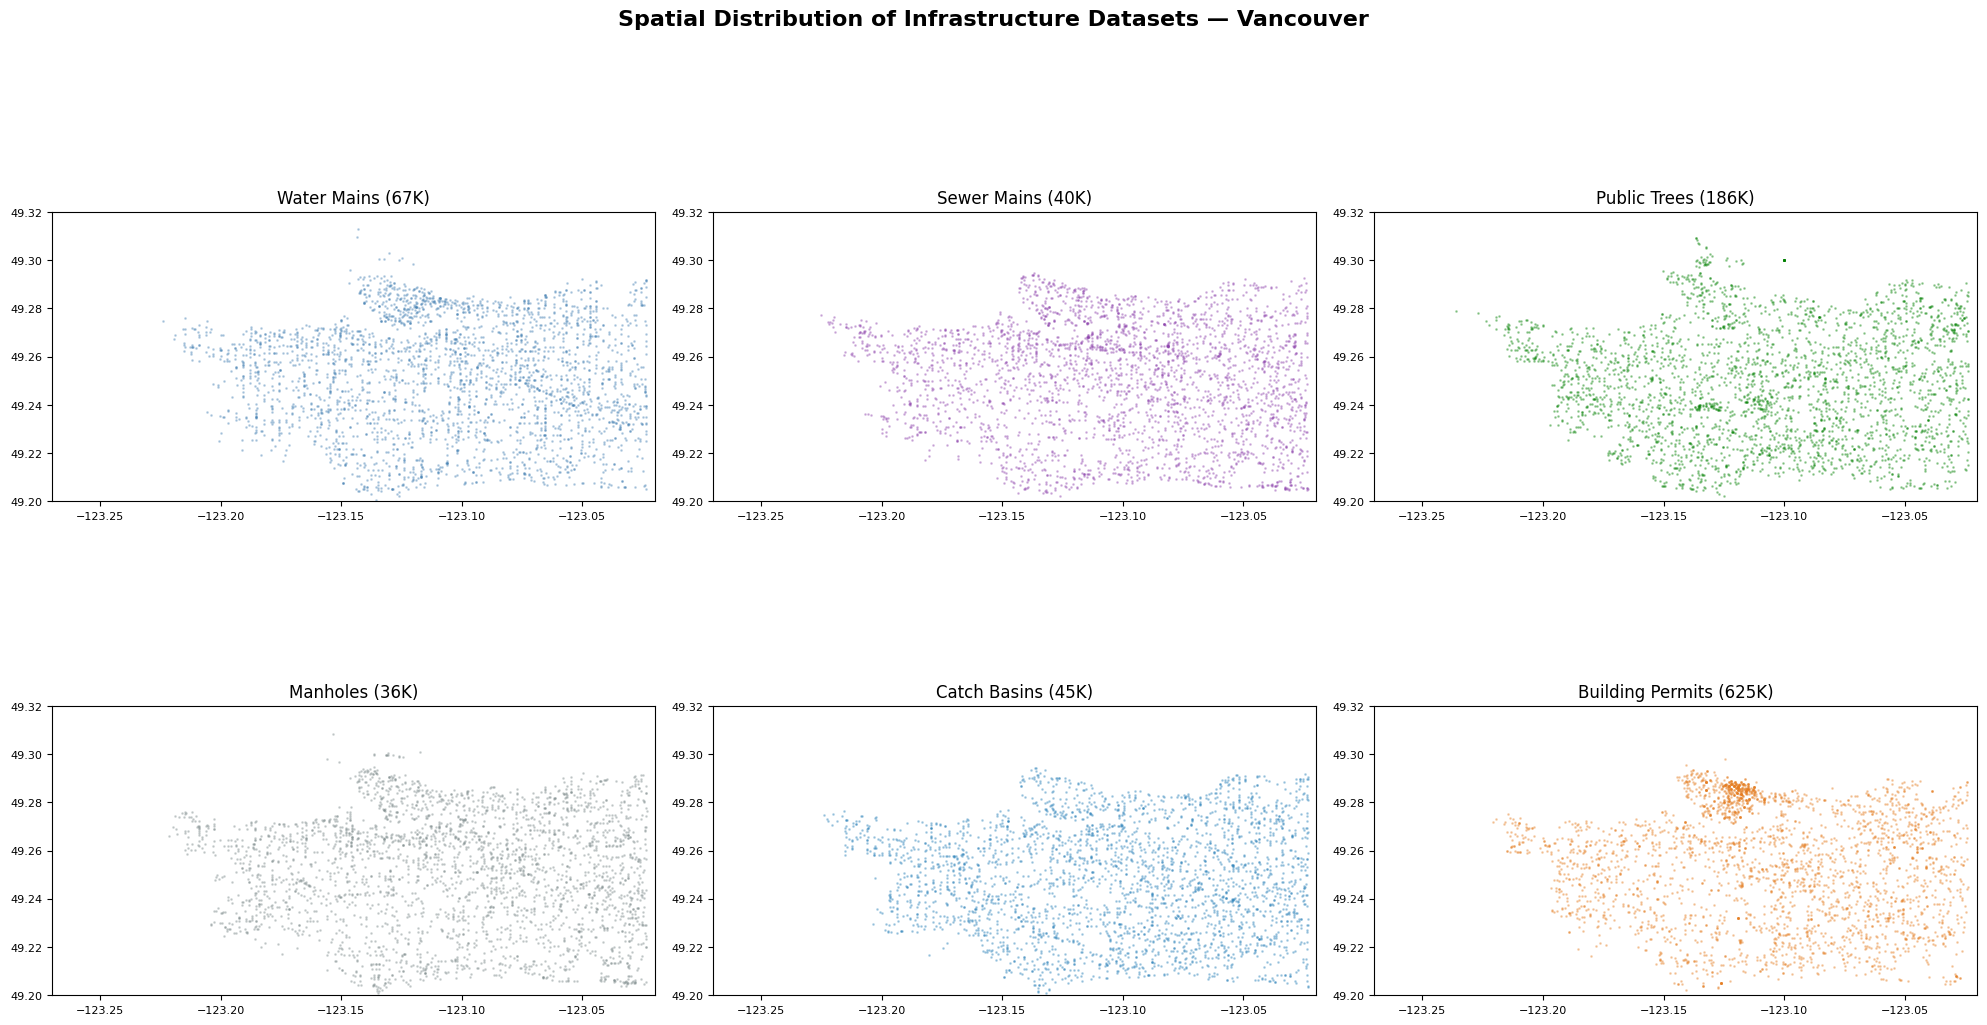

In [15]:
# Sample points from each dataset for scatter plot
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

datasets = [
    (df_water, 'Water Mains (67K)', 'steelblue'),
    (df_sewer, 'Sewer Mains (40K)', '#8e44ad'),
    (df_trees, 'Public Trees (186K)', 'green'),
    (df_manhole, 'Manholes (36K)', '#7f8c8d'),
    (df_basin, 'Catch Basins (45K)', '#2980b9'),
    (df_permit, 'Building Permits (625K)', '#e67e22'),
]

for ax, (df_plot, title, color) in zip(axes.flat, datasets):
    df_s = add_latlon(df_plot.copy())
    df_s = df_s.dropna(subset=['lat','lon'])
    sample = df_s.sample(min(3000, len(df_s)), random_state=42)
    ax.scatter(sample['lon'], sample['lat'], s=1, alpha=0.3, c=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-123.27, -123.02)
    ax.set_ylim(49.20, 49.32)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=8)

plt.suptitle('Spatial Distribution of Infrastructure Datasets — Vancouver', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 12. Dataset Size Summary & Feature Contribution

How each infrastructure dataset contributes to the final model features.

INFRASTRUCTURE DATASET SUMMARY — 10 datasets, 18 engineered features
         Dataset       Records                                     Model Features                              Proxy For
     Water Mains           67K               water_main_count, water_main_avg_age    Underground pipe stress, trench age
     Sewer Mains           40K               sewer_main_count, sewer_combined_pct Subsurface drainage, ground settlement
    Public Trees          186K tree_count_30m, tree_avg_diameter, tree_avg_height            Root damage, canopy shading
    Truck Routes 3 multi-lines                                     is_truck_route             4th-power axle load damage
Zoning Districts          1.6K                       is_industrial, is_commercial            Traffic pattern by land use
        Bikeways          3.7K                            is_bikeway, speed_limit             Road type, recent upgrades
Building Permits          625K                permit_count_200m, permit_avg_value   

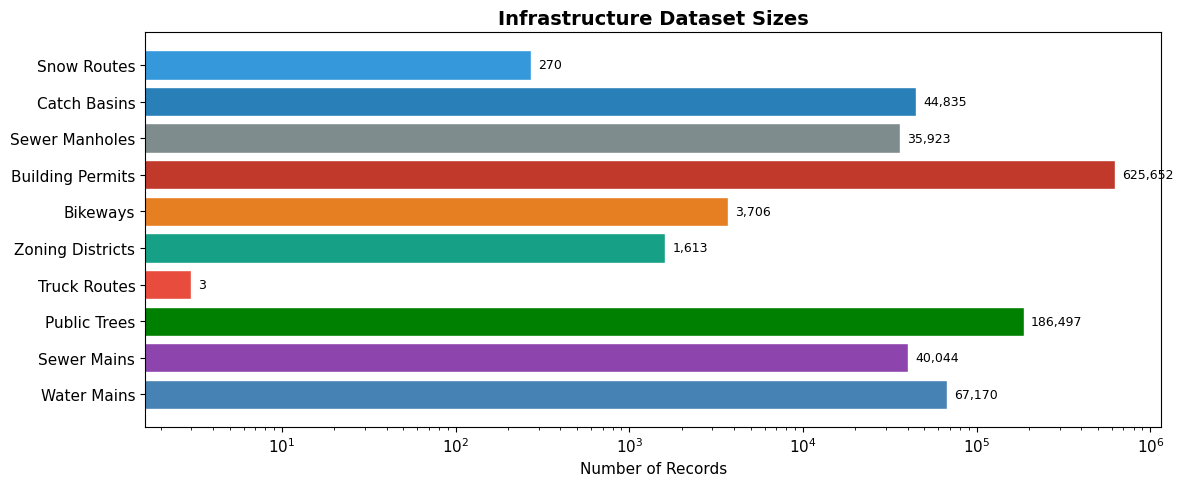


Total infrastructure records: 1,005,713
All processed via KDTree spatial proximity queries (30m–200m radius)


In [16]:
summary = pd.DataFrame({
    'Dataset': ['Water Mains', 'Sewer Mains', 'Public Trees', 'Truck Routes',
                'Zoning Districts', 'Bikeways', 'Building Permits',
                'Sewer Manholes', 'Catch Basins', 'Snow Routes'],
    'Records': ['67K', '40K', '186K', '3 multi-lines', '1.6K', '3.7K',
                '625K', '36K', '45K', '270'],
    'Model Features': [
        'water_main_count, water_main_avg_age',
        'sewer_main_count, sewer_combined_pct',
        'tree_count_30m, tree_avg_diameter, tree_avg_height',
        'is_truck_route',
        'is_industrial, is_commercial',
        'is_bikeway, speed_limit',
        'permit_count_200m, permit_avg_value',
        'manhole_count_50m',
        'catch_basin_count_50m',
        'is_snow_route',
    ],
    'Proxy For': [
        'Underground pipe stress, trench age',
        'Subsurface drainage, ground settlement',
        'Root damage, canopy shading',
        '4th-power axle load damage',
        'Traffic pattern by land use',
        'Road type, recent upgrades',
        'Recent construction disturbance',
        'Pavement weak points (cover settling)',
        'Drainage quality (runoff collection)',
        'Salt corrosion + plow scraping',
    ]
})

print('='*80)
print('INFRASTRUCTURE DATASET SUMMARY — 10 datasets, 18 engineered features')
print('='*80)
print(summary.to_string(index=False))

# Visual summary
fig, ax = plt.subplots(figsize=(12, 5))
sizes = [67170, 40044, 186497, 3, 1613, 3706, 625652, 35923, 44835, 270]
names = summary['Dataset'].tolist()
colors = ['steelblue','#8e44ad','green','#e74c3c','#16a085',
          '#e67e22','#c0392b','#7f8c8d','#2980b9','#3498db']
bars = ax.barh(range(len(names)), sizes, color=colors, edgecolor='white')
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.set_xlabel('Number of Records')
ax.set_title('Infrastructure Dataset Sizes', fontsize=14, fontweight='bold')
ax.set_xscale('log')
for i, v in enumerate(sizes):
    ax.text(v * 1.1, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

total = sum(sizes)
print(f'\nTotal infrastructure records: {total:,}')
print(f'All processed via KDTree spatial proximity queries (30m–200m radius)')